In [80]:
import numpy as np
import jax
import jax.numpy as jnp
from scipy.integrate import odeint

from rodeo.ibm import ibm_init
import ibm_nb
from rodeo.ode import *
from fenrir_filter import *

from jax.config import config
config.update("jax_enable_x64", True)

def abs_err(arr1, arr2):
    return np.sum(np.abs(arr1 - arr2))

def fitz(X_t, t, theta):
    "FitzHugh-Nagumo ODE."
    a, b, c = theta
    V, R = X_t[:,0]
    return jnp.array([[c*(V - V*V*V/3 + R)],
                    [-1/c*(V - a + b*R)]])
def fitz_nb(X, t, theta):
    "FitzHugh-Nagumo ODE function for jax."
    a, b, c = theta
    p = len(X)//2
    V, R = X[0], X[p]
    return jnp.array([c*(V - V*V*V/3 + R),
                      -1/c*(V - a + b*R)])


In [116]:
# problem setup and intialization
n_deriv = 3  # Total state
n_var = 2  # Total measures
n_dim = 2

# it is assumed that the solution is sought on the interval [tmin, tmax].
n_res = 9
tmin = 0.
tmax = 40.
n_steps = int(n_res*tmax)
theta = np.array([0.2, 0.2, 3])
thetaj = jnp.array(theta)

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .2
sigma = jnp.array([sigma]*n_var)

# Initial W for jax block
W_mat = np.zeros((n_var, 1, n_deriv))
W_mat[:, :, 1] = 1
W_block = jnp.array(W_mat)

# Initial x0 for odeint
ode0 = np.array([-1., 1.])

# Initial x0 for jax block
x0_block = jnp.array([[-1., 1., 1.], [1., 1/3, -0.3555555555555555]])
# x0_block = jnp.array([[-1., 1., 0.], [1., 1/3, 0.]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_steps
n_order = jnp.array([n_deriv]*n_var)
ode_init = ibm_init(dt, n_order, sigma)

tseq = jnp.linspace(tmin, tmax, n_steps+1)

# Jit solver
key = jax.random.PRNGKey(0)
sim_jit = jax.jit(solve_mv, static_argnums=(1, 7))
sim, _ = sim_jit(key=key, fun=fitz,
        x0=x0_block, theta=thetaj,
        tmin=tmin, tmax=tmax, n_steps=n_steps,
        W=W_block, **ode_init)

In [117]:
def fitz0(X_t, t, theta):
    a, b, c = theta
    V, R = X_t 
    return np.array([c*(V - V*V*V/3 + R), -1/c*(V - a + b*R)])

n_obs = 40
tseq1 = np.linspace(tmin, tmax, n_obs+1)
exact = odeint(fitz0, ode0, tseq1, args=(theta,))
#der = jnp.array([fitz0(exact[t],tseq[t],theta) for t in range(n_eval+1)])

gamma = .2
e_t = np.random.default_rng(0).normal(loc=0.0, scale=1, size=exact.shape)
obs = exact + gamma*e_t

In [118]:

mean_obs = jnp.zeros((n_dim,))
trans_obs = np.zeros((n_var, n_deriv*n_var))
trans_obs[0, 0] = 1
trans_obs[1, 3] = 1
trans_obs = jnp.array(trans_obs)
var_obs = gamma**2*jnp.eye((n_dim))

In [119]:
x0_state = x0_block.flatten()

# Initial W for jax non block
W = np.zeros((n_var, n_var*n_deriv))
W[0, 1] = 1
W[1, 4] = 1
W = jnp.array(W)

ode_init = ibm_nb.ibm_init(dt, n_order, sigma)
kinit = ibm_nb.indep_init(ode_init, n_order)
ode_init = dict((k, jnp.array(v)) for k, v in kinit.items())
trans_state, mean_state, var_state = ode_init.values()

In [120]:
fenrir_jit = jax.jit(fenrir_filter, static_argnums=(0, 6))
m_smooth, v_smooth = fenrir_jit(fitz_nb, W, x0_state, theta, tmin, tmax, n_res,
                         trans_state, mean_state, var_state,
                         trans_obs, mean_obs, var_obs, obs)

In [121]:
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
print("fenrir: {}".format(abs_err(exact1[:, [0,1]], m_smooth[:, [0,3]])))
print("original: {}".format(abs_err(exact1[:, [0,1]], sim[:, [0,1], 0])))

fenrir: 56.58804067382033
original: 54.52896866337003


In [103]:
filt_out, state_par, mean_smooth, var_smooth = rfenrir_filter(fitz_nb, W, x0_state, theta, tmin, tmax, n_res,
                         trans_state, mean_state, var_state,
                         trans_obs, mean_obs, var_obs, obs)

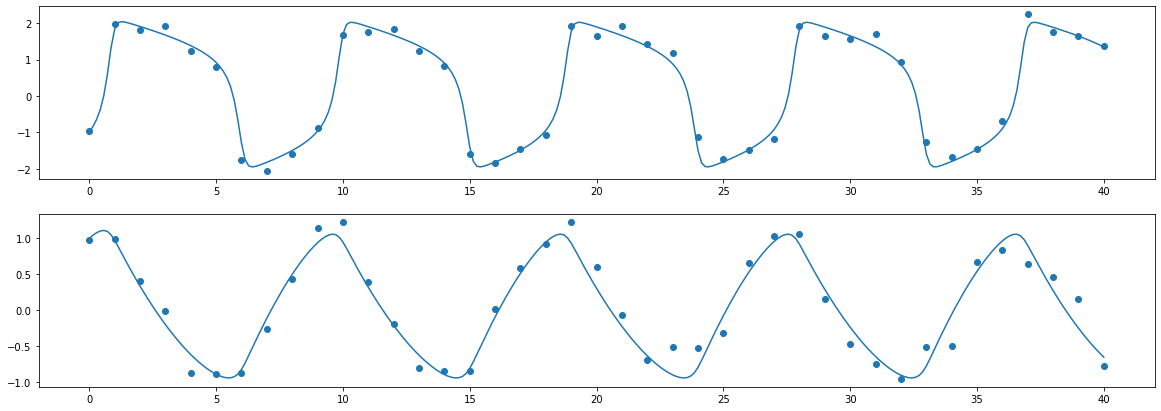

In [75]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, exact1[:, i], label='Exact')
    axs[i].plot(tseq, mean_smooth[:, i*3])
    axs[i].scatter(tseq1, obs[:, i], label='Obs')

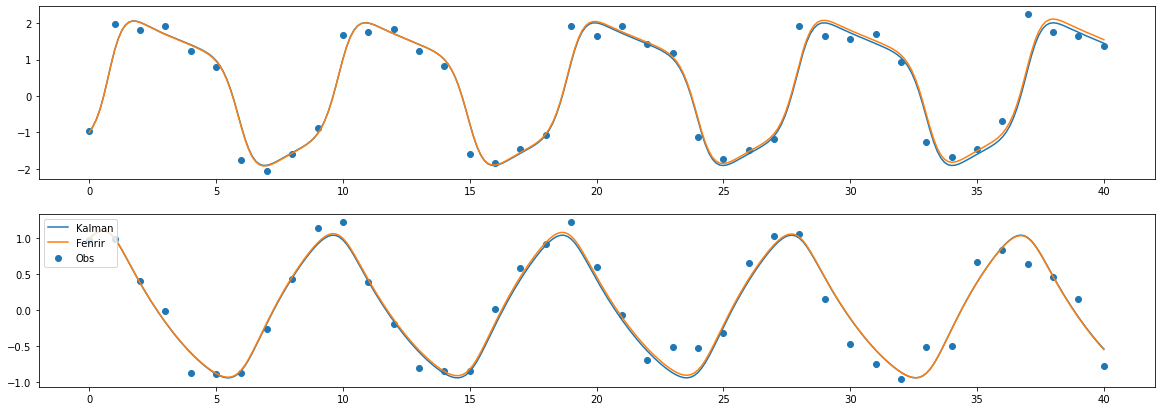

In [79]:
import matplotlib.pyplot as plt
_, axs = plt.subplots(n_dim, 1, figsize=(20, 7))
ylabel = ['R', 'V']
exact1 = odeint(fitz0, ode0, tseq, args=(theta,))
for i in range(n_dim):
    axs[i].plot(tseq, sim[:,i, 0], label="Kalman")
    axs[i].plot(tseq, m_smooth[:, i*3], label="Fenrir")
    #axs[i].plot(tseq, knum_sim[:, n_deriv_prior[0]*i], label="Kalman2")
    # axs[i].set_ylabel(ylabel[i])
    # axs[i].plot(tseq, exact1[:, i], label='Exact')
    # axs[i].plot(tseq, filt_out['state_filt'][0][:, i*3])
    axs[i].scatter(tseq1, obs[:, i], label='Obs')
axs[1].legend(loc='upper left')